
Have you ever wondered when the best time of year to book a hotel room is? Or the optimal length of stay in order to get the best daily rate? What if you wanted to predict whether or not a hotel was likely to receive a disproportionately high number of special requests?

This hotel booking dataset can help you explore those questions!

This data set contains booking information for a city hotel and a resort hotel, and includes information such as when the booking was made, length of stay, the number of adults, children, and/or babies, and the number of available parking spaces, among other things.

All personally identifying information has been removed from the data.


https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand/

In [2]:
import pandas as pd
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Datasets/SAA/hotel_bookings.csv')

Mounted at /content/drive


In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

adr (Average Daily Rate) contiene el precio medio por día

# **PREPARACIÓN DE DATOS**

## Nulos

In [5]:
# Vamos a ver cuántos nulos hay
df.isna().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


# PREGUNTA 1: EXAMEN

1. En la práctica eliminamos el atributo ‘agent’ debido a que contiene nulos. ¿Cómo calcularías el porcentaje de nulos de dicho atributo?

Si al final no se decidiera eliminar ¿cuál crees que sería el mejor método para inferir los datos que faltan? Justifica la respuesta.


In [6]:
df["agent"].value_counts()

,count
agent,
9.0,31961
240.0,13922
1.0,7191
14.0,3640
7.0,3539
...,...
197.0,1
294.0,1
388.0,1


In [7]:
# El método usado para realizar la INFERENCIA sería rellenar con valor 0 (Categoría sin Agente)

# Justificación:
# Aunque la columna 'agent' tiene números (IDs de agencia) estos son etiquetas, luego no podrías usar la Media ni Moda.
# Al imputar con 0 ("Sin Agente") preservamos la información de que no tuvo intermediario

In [8]:
porcentaje_nulos = (df['agent'].isna().sum() / len(df)) * 100

print("El porcentaje de nulos de 'agent' es " + porcentaje_nulos.round(2).astype(str) + "%")

El porcentaje de nulos de 'agent' es 13.69%


In [9]:
# Vamos a eliminar agent y company debido al alto porcentaje de nulos que contiene
df = df.drop(labels=['agent', 'company'], axis=1)

In [10]:
# Como tenemos muchos registros podemos simplemente eliminar aquellos que contienen nulos
df = df.dropna()

## Variables categóricas
Las variables categóricas representan atributos discretos que no se pueden interpretar como valores numéricos directos.

Al codificar estas variables de manera adecuada, podemos transformarlas en formatos numéricos comprensibles para los algoritmos de modelado.

# PREGUNTA 2: EXAMEN

2. Para la variable ‘arrival_date_month’, ¿cómo haríamos si queremos asignar el 1 para el mes de enero, el 2 para el mes de febrero, y así sucesivamente?

¿Es en este caso recomendable usar One Hot Encoding? Explicar la respuesta.

Independientemente de la respuesta, aplica One Hot Encoding para la variable.


In [11]:
df["arrival_date_month"].value_counts()

,count
arrival_date_month,
August,13852
July,12628
May,11779
October,11095
April,11045
June,10927
September,10467
March,9739
February,8012


In [12]:
# Usando One Hot Encoding

# Usando pandas get_dummies
df_ohe = pd.get_dummies(df, columns=['arrival_date_month'])

# Mostramos las nuevas columnas generadas
print(df_ohe.filter(like='month_').head())

   arrival_date_month_April  arrival_date_month_August  \
0                     False                      False   
1                     False                      False   
2                     False                      False   
3                     False                      False   
4                     False                      False   

   arrival_date_month_December  arrival_date_month_February  \
0                        False                        False   
1                        False                        False   
2                        False                        False   
3                        False                        False   
4                        False                        False   

   arrival_date_month_January  arrival_date_month_July  \
0                       False                     True   
1                       False                     True   
2                       False                     True   
3                       False           

In [13]:
meses_a_numeros = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}

# Aplicamos el cambio
df['arrival_date_month'] = df['arrival_date_month'].map(meses_a_numeros)

In [14]:
df['arrival_date_month'].value_counts()

,count
arrival_date_month,
8,13852
7,12628
5,11779
10,11095
4,11045
6,10927
9,10467
3,9739
2,8012


In [15]:
# No es recomendable usar One Hot Encoding para los meses
# Pérdida de Orden, trata a "Enero" y "Agosto" como dos categorías diferentes
# Alta Dimensionalidad, creas 12 columnas nuevas
# Alternativa Mejor, lo ideal para variables cíclicas como los meses, lo ideal es usar "Cyclical Encoding"

In [16]:
columns = df[['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type',
              'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status']]

for column in columns:
  df[column] = df[column].astype('category').cat.codes

## country

In [17]:
df.country.unique()

array(['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA', 'ROU', 'NOR', 'OMN',
       'ARG', 'POL', 'DEU', 'BEL', 'CHE', 'CN', 'GRC', 'ITA', 'NLD',
       'DNK', 'RUS', 'SWE', 'AUS', 'EST', 'CZE', 'BRA', 'FIN', 'MOZ',
       'BWA', 'LUX', 'SVN', 'ALB', 'IND', 'CHN', 'MEX', 'MAR', 'UKR',
       'SMR', 'LVA', 'PRI', 'SRB', 'CHL', 'AUT', 'BLR', 'LTU', 'TUR',
       'ZAF', 'AGO', 'ISR', 'CYM', 'ZMB', 'CPV', 'ZWE', 'DZA', 'KOR',
       'CRI', 'HUN', 'ARE', 'TUN', 'JAM', 'HRV', 'HKG', 'IRN', 'GEO',
       'AND', 'GIB', 'URY', 'JEY', 'CAF', 'CYP', 'COL', 'GGY', 'KWT',
       'NGA', 'MDV', 'VEN', 'SVK', 'FJI', 'KAZ', 'PAK', 'IDN', 'LBN',
       'PHL', 'SEN', 'SYC', 'AZE', 'BHR', 'NZL', 'THA', 'DOM', 'MKD',
       'MYS', 'ARM', 'JPN', 'LKA', 'CUB', 'CMR', 'BIH', 'MUS', 'COM',
       'SUR', 'UGA', 'BGR', 'CIV', 'JOR', 'SYR', 'SGP', 'BDI', 'SAU',
       'VNM', 'PLW', 'QAT', 'EGY', 'PER', 'MLT', 'MWI', 'ECU', 'MDG',
       'ISL', 'UZB', 'NPL', 'BHS', 'MAC', 'TGO', 'TWN', 'DJI', 'STP',
       'KNA', 'ETH', 

Para simplificar vamos a usar el continente en vez del país, para lo cual instalamos dos paquetes que facilitan la conversión entre nombre de países ISO, códigos de país y nombre de continentes.

In [18]:
!pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 51.4 MB/s eta 0:00:00


In [19]:
!pip install pycountry-convert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.5/253.5 kB 6.1 MB/s eta 0:00:00


In [20]:
import pycountry_convert as pc

def country_to_continent(country_name):
    try:
      if(len(country_name) > 2):
        country_alpha2 = pc.country_alpha3_to_country_alpha2(country_name)
      else:
        country_alpha2 = country_name
      country_continent_name = pc.country_alpha2_to_continent_code(country_alpha2)
      return country_continent_name
    except:
      return 'PRT'

In [21]:
df['continent'] = df['country'].map(lambda x: country_to_continent(x))

In [22]:
df.continent.value_counts()

,count
continent,
EU,107822
AS,4468
SA,2708
NA,2274
AF,1113
OC,506
PRT,7


Cómo casi todos son de Europa, para simplificar, vamos a ceñirnos a dicho continente y eliminaremos el resto

In [23]:
df.drop(df[(df['continent'] != 'EU')].index, inplace=True)

# PREGUNTA 3: EXAMEN

3. Para la siguiente instrucción:

df.drop(df[(df['continent'] != 'EU')].index, inplace=True)

¿cómo sería sin el inplace?



In [24]:
#df = df.drop(df[(df['continent'] != 'EU')].index)

In [25]:
# ¿Por qué se hace así?
# Cuando usas inplace=True, Pandas modifica el objeto original directamente y no devuelve nada.
# Si quitas ese parámetro, la función .drop() genera una copia del DataFrame con las filas eliminadas.
#Para no perder esos cambios, necesitas "sobrescribir" la variable original.

In [26]:
df.country.unique()

array(['PRT', 'GBR', 'ESP', 'IRL', 'FRA', 'ROU', 'NOR', 'POL', 'DEU',
       'BEL', 'CHE', 'GRC', 'ITA', 'NLD', 'DNK', 'RUS', 'SWE', 'EST',
       'CZE', 'FIN', 'LUX', 'SVN', 'ALB', 'UKR', 'SMR', 'LVA', 'SRB',
       'AUT', 'BLR', 'LTU', 'HUN', 'HRV', 'AND', 'GIB', 'JEY', 'GGY',
       'SVK', 'MKD', 'BIH', 'BGR', 'MLT', 'ISL', 'MCO', 'IMN', 'LIE',
       'MNE', 'FRO'], dtype=object)

In [27]:
df['country'] = df['country'].astype('category').cat.codes
df = df.drop(labels=['continent'], axis=1)

## reservation_status_date

In [28]:
# Contiene la fecha del último cambio en el estado de la reserva
# No parece muy significativo, así que eliminamos el atributo

df = df.drop(labels=['reservation_status_date'], axis=1)

# **REDUCCIÓN DIMENSIONALIDAD**

# PREGUNTA 4: EXAMEN

4. ¿En la variable ‘adr’ aparecen outliers? Explícalo


In [29]:
def detectar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]

    print(f"Variable: {columna}")
    print(f"Límite Inferior: {limite_inferior}")
    print(f"Límite Superior: {limite_superior}")
    print(f"Total de outliers detectados: {len(outliers)}")

    return outliers

In [30]:
out_adr = detectar_outliers(df, 'adr')

Variable: adr
Límite Inferior: -16.68875
Límite Superior: 208.94125
Total de outliers detectados: 3590


In [31]:
# Valores negativos: A veces aparece un valor de -6.38. Esto es un outlier técnico (un error), ya que una tarifa no debería ser negativa.

# El valor extremo: Existe un registro con un adr superior a 5,000. Comparado con la media (que suele rondar los 100-150),
# este es un outlier clarísimo que puede distorsionar cualquier promedio o modelo de Machine Learning.

# Valores en 0: Hay muchos registros con adr = 0. Dependiendo del análisis, podrías considerarlos outliers o simplemente cortesías del hotel.

## **Feature importance**

In [32]:
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier

# Vamos a coger como variable objetivo 'is_cancelled'
X = df.drop(labels=['is_canceled'], axis=1)
y = df['is_canceled']
model = ExtraTreesClassifier()
model.fit(X,y)


ExtraTreesClassifier()

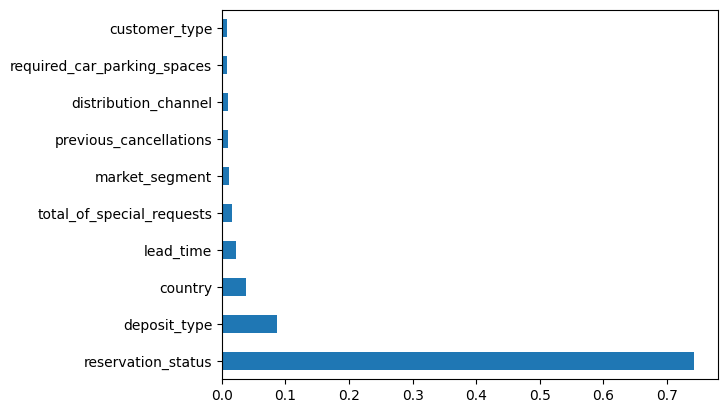

In [33]:
# Mostramos las 10 características más importantes
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

## **Correlation (Pearson)**

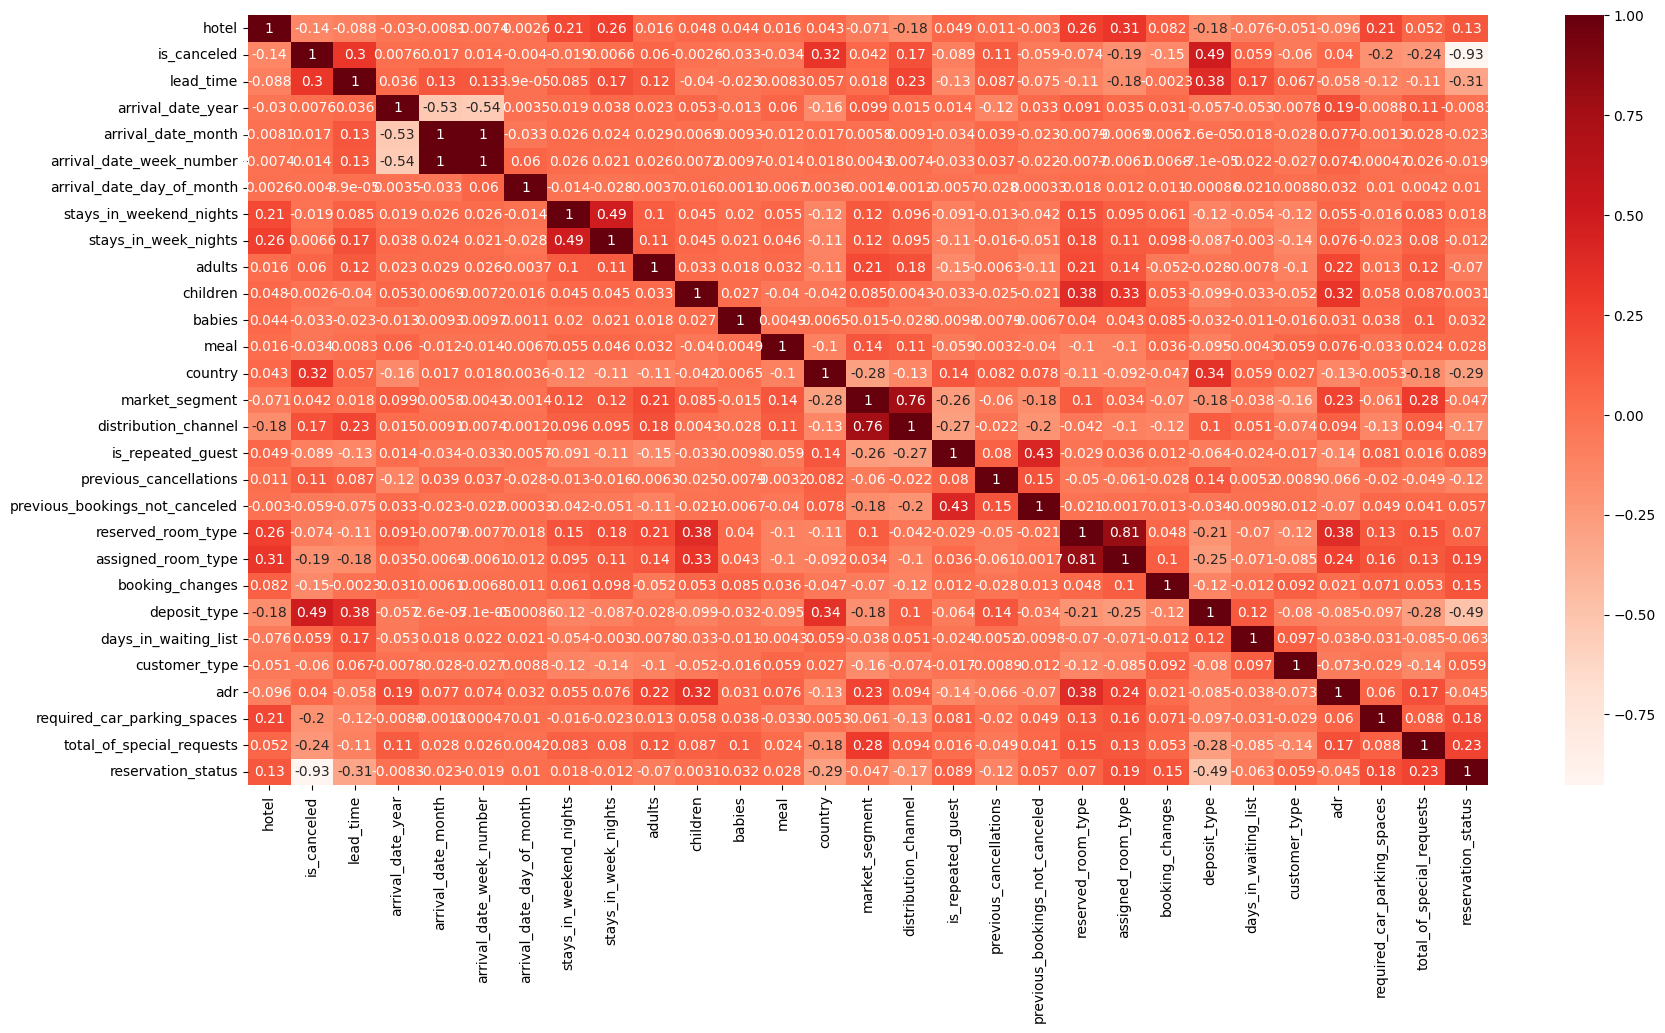

In [34]:
import seaborn as sns

plt.figure(figsize=(20,10))
cor = df.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

# PREGUNTA 5: EXAMEN

5. ¿Qué correlación tienen las variables ‘reserved_room_type’ y ‘assigned_room_type’? Escribe la sentencia.


¿Te quedarías con las dos? Si tuvieses que quedarte con una, ¿cuál sería? Explica la razón.



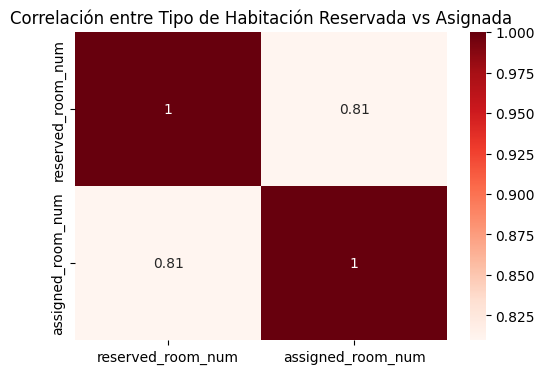

El coeficiente de correlación es: 0.8097295256418221


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Convertimos las categorías (letras) en números para poder calcular la correlación
df_temp = df[['reserved_room_type', 'assigned_room_type']].copy()
df_temp['reserved_room_num'] = df_temp['reserved_room_type'].astype('category').cat.codes
df_temp['assigned_room_num'] = df_temp['assigned_room_type'].astype('category').cat.codes

# 2. Calculamos la correlación de Pearson específicamente para estas dos
correlacion = df_temp[['reserved_room_num', 'assigned_room_num']].corr()

# 3. Visualizamos el Heatmap pequeño
plt.figure(figsize=(6,4))
sns.heatmap(correlacion, annot=True, cmap=plt.cm.Reds)
plt.title('Correlación entre Tipo de Habitación Reservada vs Asignada')
plt.show()

print(f"El coeficiente de correlación es: {correlacion.iloc[0,1]}")

In [36]:
#¿Te quedarías con las dos?
#No.
#Si tu objetivo es crear un modelo predictivo (como predecir si una reserva se cancelará), mantener ambas variables es redundante.
# Como vimos, tienen una correlación muy alta, lo que significa que aportan información casi idéntica. Incluir ambas puede confundir a ciertos algoritmos
# (como la Regresión Logística), haciendo que el modelo sea menos estable.

In [37]:
# No me quedaría con las dos debido a la alta correlación.
# Elegiría reserved_room_type porque es una variable conocida en el momento de la reserva,
# permitiendo realizar predicciones tempranas, y representa mejor la segmentación del cliente

# PREGUNTA 6: EXAMEN

6. En la práctica, ¿qué normalizaciones de datos aparecen? ¿en qué consisten?



1. Estandarización (StandardScaler):

    En qué consiste: Transforma los datos para que tengan una media de 0 y una desviación estándar de 1. Los valores se expresan en términos de cuántas desviaciones típicas se alejan de la media.

    Cuándo usarla: Cuando los datos siguen una distribución normal o cuando el algoritmo es sensible a la escala (ej. SVM, KNN). Es robusta frente a outliers.

2. Normalización Min-Max (MinMaxScaler):

    En qué consiste: Escala los datos dentro de un rango fijo, típicamente entre 0 y 1.

    Cuándo usarla: Cuando no se conoce la distribución de los datos o en algoritmos como Redes Neuronales. Es muy sensible a outliers (estos pueden comprimir los demás datos).


Explicación de la sentencia:

    scaler = StandardScaler(): Define el método de estandarización.

    fit_transform(X): Fit calcula la media y desviación del conjunto X, y Transform aplica la fórmula de estandarización a cada valor.

## **PCA**

# PREGUNTA 7: EXAMEN

7. Al aplicar PCA, suponiendo que ‘is_canceled’ es la variable objetivo, ¿con cuántas variables nos quedaríamos? Explica la respuesta.

In [38]:
# Nos quedaríamos con el número mínimo de componentes (PC1, PC2, etc.) cuya suma de varianza alcance el umbral deseado (ej. 85%),
# permitiendo que el modelo sea más rápido y eficiente sin perder precisión.

# PREGUNTA 8: EXAMEN

8. Si la variable objetivo es ‘is_canceled’, ¿es un problema de clasificación o de regresión?

In [39]:
df['is_canceled'].value_counts()

,count
is_canceled,
0,67214
1,40608


In [40]:
# La variable 'is_canceled' es un problema de clasificación en concreto clasificación binaria

Diferencia con Regresión

    Regresión: Se usa cuando queremos predecir un número infinito de valores posibles (ej. el precio de una habitación, la temperatura o el valor del adr).

    Clasificación (nuestro caso): Se usa cuando queremos asignar una observación a una categoría específica.



# PREGUNTA 8: EXAMEN

8. Si la variable objetivo es ‘adr, ¿es un problema de clasificación o de regresión? Razona la respuesta.

In [41]:
df['adr'].value_counts()

,count
adr,
62.00,3736
75.00,2577
90.00,2329
65.00,2290
0.00,1884
...,...
109.39,1
124.59,1
149.79,1


In [42]:
# La variable 'adr' es un problema de regresión

### En el caso de que la variable objetivo sea 'is_canceled'

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df.drop(labels=['is_canceled'], axis=1)
y = df['is_canceled']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Con 20 componentes
modelo_pca = PCA(n_components=20)
modelo_pca.fit(X_scaled)
X_pca = modelo_pca.transform(X_scaled)

# components_ devuelve cómo influye cada atributo original en los nuevos atributos
pd.DataFrame(
    data     = modelo_pca.components_,
    columns  = X.columns,
    index    = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
                'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20']
)

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
PC1,0.186337,-0.151681,0.133840,-0.050951,-0.051638,0.008725,0.189684,0.191182,0.166860,0.233042,...,0.400839,0.380856,0.086729,-0.313728,-0.108747,-0.110509,0.266487,0.122369,0.253463,0.203580
PC2,-0.156438,0.288521,-0.079768,0.204932,0.202879,-0.002136,0.124821,0.141181,0.210449,0.000722,...,-0.052115,-0.136169,-0.104209,0.160559,0.070740,-0.086855,0.139680,-0.170886,0.026444,-0.247224
PC3,0.130408,-0.005456,-0.447638,0.568846,0.572202,0.012936,0.036398,0.034026,-0.011306,0.055427,...,0.105381,0.136252,0.056311,-0.051623,-0.002023,-0.021915,0.006192,0.095117,0.007974,0.069325
PC4,-0.153289,-0.239109,-0.081392,0.111445,0.112817,-0.002369,-0.094611,-0.154911,-0.113116,-0.229109,...,-0.334764,-0.268963,0.048150,-0.377524,-0.071136,0.124974,-0.127138,-0.009955,0.216020,0.396527
PC5,0.365156,0.180263,-0.009984,-0.055508,-0.060730,-0.072440,0.507499,0.530408,-0.050015,-0.256823,...,-0.151153,-0.131735,0.176235,-0.048784,-0.001837,-0.024074,-0.321162,-0.012415,-0.038339,0.063271
PC6,-0.052027,-0.068679,0.017725,0.017802,0.010235,-0.078954,0.070410,0.035572,0.054679,-0.067153,...,-0.051670,-0.084104,-0.257730,0.032040,-0.192969,-0.443143,-0.016516,-0.012630,0.285533,-0.087697
PC7,-0.232478,0.312998,0.210772,0.066163,0.069115,0.085466,0.021783,0.076527,-0.001237,0.179633,...,-0.014084,-0.062307,0.390149,-0.021832,0.289997,0.317764,0.274701,-0.096090,0.117666,-0.012102
PC8,0.061280,0.024422,0.005446,-0.035236,-0.026637,0.096429,-0.111748,-0.080153,0.087093,-0.089274,...,-0.113211,-0.105357,0.230478,0.156803,-0.046036,-0.179530,0.005522,0.323055,0.281058,-0.031668
PC9,0.201948,0.127649,-0.094859,-0.082228,-0.042531,0.392043,-0.114350,-0.063307,0.152110,-0.163250,...,0.057806,0.115336,-0.141552,-0.019426,0.566311,0.114793,-0.220703,0.357012,0.067460,0.135760
PC10,-0.172497,0.017700,0.119924,0.025538,0.085633,0.661560,0.155585,0.138357,-0.156182,0.015187,...,-0.052915,-0.092518,0.005006,0.027508,-0.022566,-0.244035,0.045909,-0.208012,0.072528,0.007196


In [44]:
print("shape of X_pca", X_pca.shape)
expl = modelo_pca.explained_variance_ratio_
print(expl)
print('suma:',sum(expl[0:20]))

shape of X_pca (107822, 20)
[0.11465282 0.09481143 0.08621835 0.0649288  0.0563887  0.04804934
 0.04213331 0.03799447 0.03664265 0.03615619 0.03515067 0.03385178
 0.0326545  0.03194087 0.02951215 0.02813612 0.02623943 0.02556738
 0.02341278 0.02057249]
suma: 0.9050142427320971


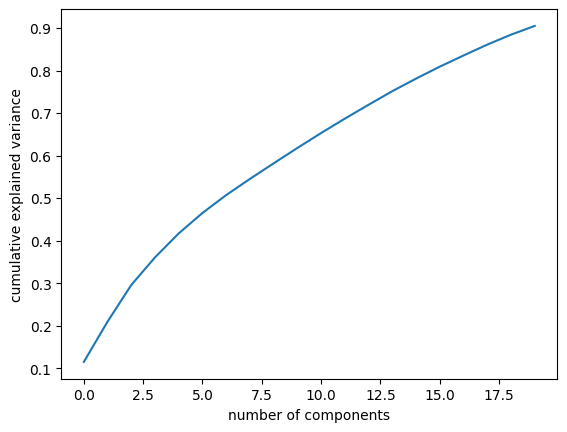

In [45]:
plt.plot(np.cumsum(modelo_pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()

### En el caso de que la variable objetivo sea 'adr'

In [46]:
X = df.drop(labels=['adr'], axis=1)
y = df['adr']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Con 20 componentes
modelo_pca = PCA(n_components=20)
modelo_pca.fit(X_scaled)
X_pca = modelo_pca.transform(X_scaled)

# components_ devuelve cómo influye cada atributo original en los nuevos atributos
pd.DataFrame(
    data     = modelo_pca.components_,
    columns  = X.columns,
    index    = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
                'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20']
)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,required_car_parking_spaces,total_of_special_requests,reservation_status
PC1,-0.206467,0.393927,0.249528,-0.087850,0.068894,0.068117,-0.006011,-0.111750,-0.099873,-0.042577,...,-0.032295,-0.289559,-0.326430,-0.122921,0.381041,0.110524,0.038626,-0.168746,-0.228085,-0.389609
PC2,-0.002163,0.158081,0.187281,0.042554,0.072200,0.069589,-0.003702,0.235971,0.253659,0.270308,...,-0.249902,0.172535,0.089098,-0.051377,-0.000354,-0.002564,-0.150104,-0.094771,0.137892,-0.164161
PC3,0.084348,-0.059717,0.039791,-0.465116,0.600755,0.603844,0.011416,0.044861,0.042141,0.010206,...,0.007917,0.051773,0.074699,0.037566,-0.033243,0.015059,-0.021700,0.058441,0.013083,0.056826
PC4,0.265004,0.301085,0.073333,0.054748,-0.083083,-0.083774,0.001206,0.120298,0.161975,0.073245,...,0.094240,0.413109,0.376055,0.010864,0.189459,-0.020490,-0.136239,0.088409,-0.118786,-0.298579
PC5,0.285793,-0.063074,0.231525,0.039961,-0.043087,-0.048891,-0.063926,0.491915,0.524692,-0.078619,...,0.040462,-0.216814,-0.216567,0.240252,-0.005641,0.049911,0.063393,-0.026753,-0.081761,0.059624
PC6,-0.037687,0.059449,-0.095331,0.022881,0.029147,0.021225,-0.081935,0.102305,0.061787,0.024282,...,0.499546,-0.094309,-0.122369,-0.209575,-0.024873,-0.215509,-0.412056,-0.012211,0.305516,-0.061909
PC7,-0.218438,-0.022176,0.352469,0.147208,0.034772,0.044003,0.133962,-0.092688,-0.022676,0.051455,...,0.351137,0.101499,0.084651,0.326031,-0.014441,0.443459,0.337437,-0.075490,0.138515,0.013300
PC8,0.056151,0.057935,-0.011482,0.012146,-0.021424,-0.013562,0.091856,-0.111765,-0.089309,0.042216,...,-0.107934,-0.111766,-0.102987,0.285608,0.110696,-0.104029,-0.131375,0.279761,0.280358,-0.058422
PC9,0.082622,-0.186544,0.188944,-0.022823,-0.074027,-0.046369,0.278367,-0.021362,0.036644,0.262750,...,-0.012851,-0.033331,-0.025058,-0.261778,0.171352,0.466806,-0.198342,0.378451,0.082633,0.180603
PC10,-0.189878,0.046808,-0.018532,0.114087,0.035854,0.093840,0.639231,0.150330,0.122106,-0.241271,...,0.059031,-0.030524,-0.064979,0.085183,-0.019186,-0.100268,-0.181974,-0.315538,0.064726,-0.033815


In [47]:
print("shape of X_pca", X_pca.shape)
expl = modelo_pca.explained_variance_ratio_
print(expl)
print('suma:',sum(expl[0:20]))

shape of X_pca (107822, 20)
[0.12213275 0.09604505 0.0865819  0.07264848 0.05318936 0.0482685
 0.04052649 0.03805442 0.03679334 0.03609858 0.03558369 0.03288596
 0.03224335 0.03201512 0.02911573 0.02805074 0.02606957 0.02498235
 0.02460663 0.02123398]
suma: 0.9171259880314258


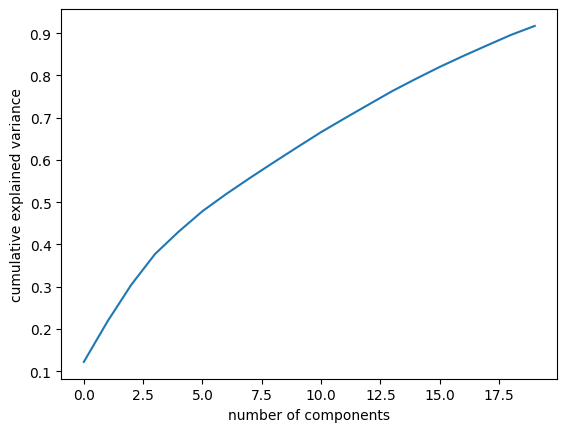

In [48]:
plt.plot(np.cumsum(modelo_pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()

# **APRENDIZAJE SUPERVISADO**

## **REGRESIÓN LOGÍSTICA**

In [49]:
# La variable objetivo es 'is_canceled'

X = df.drop(labels=['is_canceled'], axis=1)
y = df['is_canceled']

# Estandarizamos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicamos PCA para reducir dimensionalidad
modelo_pca = PCA(n_components=15)
modelo_pca.fit(X_scaled)
X_pca = modelo_pca.transform(X_scaled)

In [50]:
from sklearn.model_selection import train_test_split

# Dividimos en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size = 0.2)

In [51]:
from sklearn.linear_model import LogisticRegression
regr = LogisticRegression()

# Entrenamos el agoritmo con los datos
regr.fit(X_train, y_train)

# Hacemos las predicciones con el test
y_pred_LR = regr.predict(X_test)

In [52]:
from sklearn import metrics

# Model Accuracy: how often is the classifier correct?
print("Accuracy:", metrics.accuracy_score(y_test, y_pred_LR))

Accuracy: 0.9479712497101785


# PREGUNTA 9: EXAMEN

9. En SVM, ¿cómo podrías optimizar el parámetro correspondiente al kernel?

# PREGUNTA 10: EXAMEN

10. Código para aplicar SVM en el caso de que la variable objetivo sea ‘adr’.

## **SVM**

### Si la variable objetivo es 'is_canceled'

In [53]:
from sklearn.model_selection import train_test_split
from sklearn import svm

X = df.drop(labels=['is_canceled'], axis=1)
y = df['is_canceled']

# Estandarizamos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicamos PCA para reducir dimensionalidad
modelo_pca = PCA(n_components=15)
modelo_pca.fit(X_scaled)
X_pca = modelo_pca.transform(X_scaled)

# Dividimos en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size = 0.2)

# Create a svm Classifier
modelo_svc = svm.SVC ()

# Train the model using the training sets
modelo_svc.fit (X_train, y_train)

# Predict the response for test dataset
y_pred_SVC = modelo_svc.predict(X_test)

In [54]:
from sklearn import metrics

print("Accuracy: ", metrics.accuracy_score (y_test, y_pred_SVC))

Accuracy:  0.9875260839322977


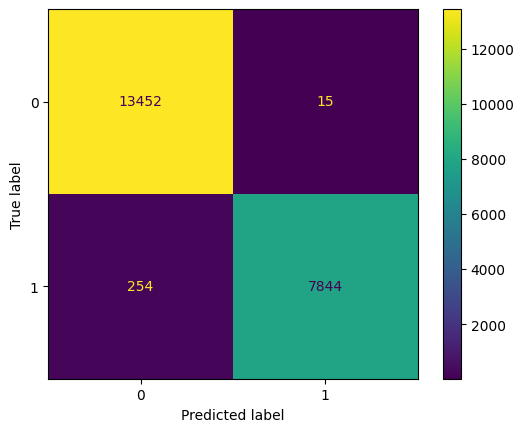

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator (modelo_svc, X_test, y_test)

In [56]:
from sklearn.metrics import classification_report

print(classification_report (y_test, y_pred_SVC))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     13467
           1       1.00      0.97      0.98      8098

    accuracy                           0.99     21565
   macro avg       0.99      0.98      0.99     21565
weighted avg       0.99      0.99      0.99     21565



### Si la variable objetivo es 'adr'

Mean Absolute Error (MAE): 22.123086659646415
R2 Score (Varianza explicada): 0.3345382712288044


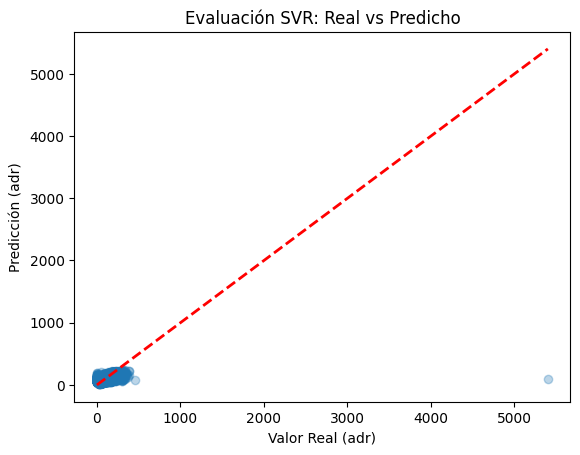

In [57]:
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import metrics
import matplotlib.pyplot as plt

# Seleccionamos solo variables numéricas y limpiamos nulos para que PCA/SVM funcionen
df_numeric = df.select_dtypes(include=['number']).fillna(0)

# Definimos X (características) e y (objetivo: 'adr')
X = df_numeric.drop(labels=['adr'], axis=1)
y = df_numeric['adr']

# Estandarizamos (obligatorio en SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicamos PCA para reducir dimensionalidad (mantenemos 15 componentes como en tu ejemplo)
modelo_pca = PCA(n_components=15)
X_pca = modelo_pca.fit_transform(X_scaled)

# Dividimos en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size = 0.2, random_state=42)

# Create a svm Regressor (SVR en lugar de SVC porque 'adr' es continua (precio))
modelo_svr = svm.SVR(kernel='rbf')

# Train the model using the training sets
modelo_svr.fit(X_train, y_train)

# Predict the response for test dataset
y_pred_SVR = modelo_svr.predict(X_test)

# Calculamos métricas de regresión (en lugar de Accuracy)
print("Mean Absolute Error (MAE):", metrics.mean_absolute_error(y_test, y_pred_SVR))
print("R2 Score (Varianza explicada):", metrics.r2_score(y_test, y_pred_SVR))

# Visualización: Gráfico de dispersión (Real vs Predicho)
# Sustituye a la Confusion Matrix ya que no hay clases, sino valores continuos
plt.scatter(y_test, y_pred_SVR, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valor Real (adr)')
plt.ylabel('Predicción (adr)')
plt.title('Evaluación SVR: Real vs Predicho')
plt.show()

## **DECISION TREES**

### Si la variable objetivo es 'is_canceled'

In [58]:
from sklearn.model_selection import train_test_split
from sklearn import svm

X = df.drop(labels=['is_canceled'], axis=1)
y = df['is_canceled']

# Estandarizamos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicamos PCA para reducir dimensionalidad
modelo_pca = PCA(n_components=15)
modelo_pca.fit(X_scaled)
X_pca = modelo_pca.transform(X_scaled)

# Dividimos en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size = 0.2)

from sklearn import tree

# Creamos y entrenamos el modelo
modelo_tree = tree.DecisionTreeClassifier()
modelo_tree.fit (X_train, y_train)

# Predicción
y_pred_tree = modelo_tree.predict(X_test)

In [59]:
print ("Accuracy: ", metrics.accuracy_score(y_test, y_pred_tree))

Accuracy:  0.9483885926269418


### Si la variable objetivo es 'adr'

Mean Absolute Error (MAE):  19.40511598851291
R2 Score:  0.2842575970644161


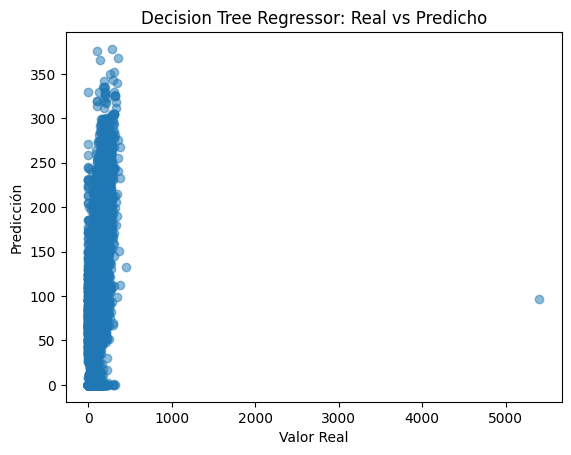

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import tree
from sklearn import metrics

# Seleccionamos variables numéricas y tratamos nulos para el análisis
df_numeric = df.select_dtypes(include=['number']).fillna(0)

# Definimos X e y (objetivo: 'adr')
X = df_numeric.drop(labels=['adr'], axis=1)
y = df_numeric['adr']

# Estandarizamos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicamos PCA para reducir dimensionalidad
modelo_pca = PCA(n_components=15)
X_pca = modelo_pca.fit_transform(X_scaled)

# Dividimos en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size = 0.2, random_state=42)

# Creamos y entrenamos el modelo
# Usamos DecisionTreeRegressor porque 'adr' es una variable continua
modelo_tree = tree.DecisionTreeRegressor()
modelo_tree.fit(X_train, y_train)

# Predicción
y_pred_tree = modelo_tree.predict(X_test)

# Métricas de evaluación para regresión
print("Mean Absolute Error (MAE): ", metrics.mean_absolute_error(y_test, y_pred_tree))
print("R2 Score: ", metrics.r2_score(y_test, y_pred_tree))

# Visualización opcional de las primeras predicciones
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred_tree, alpha=0.5)
plt.xlabel("Valor Real")
plt.ylabel("Predicción")
plt.title("Decision Tree Regressor: Real vs Predicho")
plt.show()

# **MÉTRICAS**

### Si la variable objetivo es 'is_canceled'

# PREGUNTA 11: EXAMEN

11. Si en vez de ‘is_canceled’ la variable objetivo es ‘adr’, ¿qué métricas utilizarías?

In [75]:
y_test

,adr
3905,73.33
72907,144.00
85585,82.40
60448,79.20
19537,50.00
...,...
82849,75.00
37077,131.67
35605,93.00
49420,93.90


In [73]:
print(classification_report(y_test, y_pred_LR))
print(classification_report (y_test, y_pred_SVC))
print(classification_report (y_test, y_pred_tree))

ValueError: Classification metrics can't handle a mix of continuous and binary targets

### Si la variable objetivo es 'adr'

In [1]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Definimos una función para imprimir las métricas de forma limpia
def mostrar_metricas_regresion(y_real, y_pred, nombre_modelo):
    print(f"--- Métricas para {nombre_modelo} ---")
    print(f"MAE (Error Medio Absoluto): {mean_absolute_error(y_real, y_pred):.2f}€")
    print(f"RMSE (Raíz del Error Cuadrático Medio): {np.sqrt(mean_squared_error(y_real, y_pred)):.2f}€")
    print(f"R2 Score (Varianza explicada): {r2_score(y_real, y_pred):.4f}")
    print("-" * 30)

# Suponiendo que ya tienes las predicciones guardadas:
mostrar_metricas_regresion(y_test, y_pred_LR, "Linear Regression")
mostrar_metricas_regresion(y_test, y_pred_SVR, "SVM Regressor (SVR)")
mostrar_metricas_regresion(y_test, y_pred_tree, "Decision Tree Regressor")

NameError: name 'y_test' is not defined

# PREGUNTA 12: EXAMEN

12. Si la variable objetivo es ‘is_canceled’, ¿qué algoritmo crees que es el mejor? Razona la respuesta


"Aunque el SVM presenta un mejor rendimiento estadístico (98% de Accuracy), el Árbol de Decisión (94%) podría considerarse mejor para la gestión hotelera debido a su alta interpretabilidad. No obstante, si el objetivo es maximizar la detección correcta de cancelaciones para evitar pérdidas económicas, el SVM es el algoritmo más eficaz por su mayor capacidad de separación en el espacio transformado por PCA."